In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
from itertools import product
from sklearn.metrics import confusion_matrix, accuracy_score  # only for reporting, not for training

In [5]:
APS_df = pd.read_csv('/content/drive/MyDrive/Soft Computing/Labsheet_01/APS_features.csv')
KG_df = pd.read_csv('/content/drive/MyDrive/Soft Computing/Labsheet_01/KG_features.csv')

In [12]:
APS_df = APS_df.drop(columns = ['Image'])
KG_df = KG_df.drop(columns = ['Image'])

In [14]:
APS_df.head(), KG_df.head()

(   Right Eye Width  Left Eye Width  Face Height
 0       243.002058      209.618701  1296.389216
 1       233.137299      225.574821  1323.315911
 2       222.506180      230.471256  1325.275066
 3       204.009804      206.770404  1192.403036
 4       194.010309      197.162370  1144.027972,
    Right Eye Width  Left Eye Width  Face Height
 0       107.298649      131.867358   651.512087
 1        68.264193       76.655072   403.447642
 2        30.265492       39.012818   192.262841
 3        52.773099       44.283180   270.266535
 4       117.068356      135.162865   668.554411)

In [19]:
OUT_DIR = "face_lab_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(42)

In [20]:
def prepare_df(aps_df, kg_df):
    aps = aps_df.copy()
    kg  = kg_df.copy()
    aps['label'] = 0
    kg['label']  = 1

    # compute single eye_width as average of left+right
    aps['eye_width'] = (aps['Right Eye Width'] + aps['Left Eye Width']) / 2.0
    kg['eye_width']  = (kg['Right Eye Width'] + kg['Left Eye Width']) / 2.0

    # keep only required columns
    aps2 = aps[['eye_width', 'Face Height', 'label']].rename(columns={'Face Height':'face_height'})
    kg2  = kg[['eye_width', 'Face Height', 'label']].rename(columns={'Face Height':'face_height'})

    df = pd.concat([aps2, kg2], ignore_index=True).reset_index(drop=True)
    return df

df = prepare_df(APS_df, KG_df)

df[['eye_width','face_height','label']].to_csv(os.path.join(OUT_DIR, "face_features.csv"), index=False)

print("Combined data shape:", df.shape)
print("Sample:")
print(df.head())

Combined data shape: (394, 3)
Sample:
    eye_width  face_height  label
0  226.310380  1296.389216      0
1  229.356060  1323.315911      0
2  226.488718  1325.275066      0
3  205.390104  1192.403036      0
4  195.586339  1144.027972      0


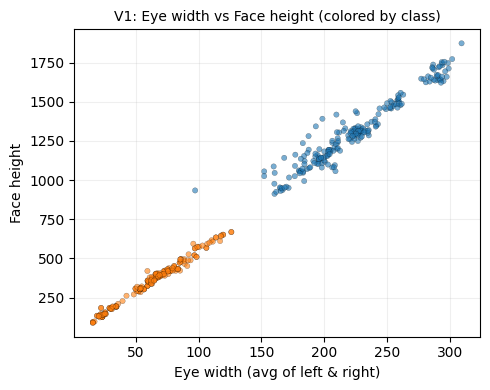

/tmp/ipython-input-1269508215.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


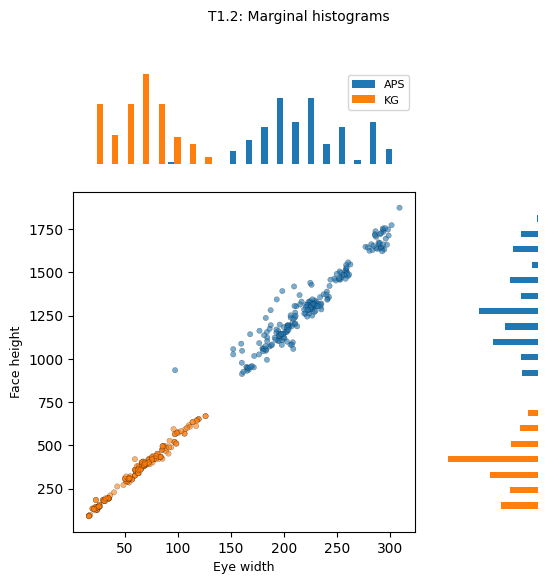

In [22]:
# Task 1 (smaller plots)

plt.figure(figsize=(5,4))   # smaller figure
colors = ['C0' if lab==0 else 'C1' for lab in df['label']]
plt.scatter(df['eye_width'], df['face_height'],
            c=colors, alpha=0.6, s=15,   # smaller marker size
            edgecolors='k', linewidths=0.2)
plt.xlabel("Eye width (avg of left & right)")
plt.ylabel("Face height")
plt.title("V1: Eye width vs Face height (colored by class)", fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "V1_scatter_eye_vs_face.png"), dpi=150)
plt.show()

# Optional: marginal histograms (T1.2)
fig = plt.figure(figsize=(6,6))  # reduced from 8x8
grid = plt.GridSpec(4,4, hspace=0.3, wspace=0.3)
main_ax = fig.add_subplot(grid[1:4,0:3])
x_hist = fig.add_subplot(grid[0,0:3], sharex=main_ax)
y_hist = fig.add_subplot(grid[1:4,3], sharey=main_ax)

main_ax.scatter(df['eye_width'], df['face_height'],
                c=colors, alpha=0.6, s=15, edgecolors='k', linewidths=0.2)
main_ax.set_xlabel("Eye width", fontsize=9)
main_ax.set_ylabel("Face height", fontsize=9)

x_hist.hist([df[df.label==0]['eye_width'], df[df.label==1]['eye_width']],
            bins=20, stacked=False, label=['APS','KG'])
x_hist.legend(fontsize=8)
y_hist.hist([df[df.label==0]['face_height'], df[df.label==1]['face_height']],
            bins=20, orientation='horizontal', stacked=False)

y_hist.invert_xaxis()
x_hist.axis('off')
y_hist.axis('off')

plt.suptitle("T1.2: Marginal histograms", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "V1_marginals.png"), dpi=150)
plt.show()


In [32]:
df

,eye_width,face_height,label,x1,x2,eye_width_norm,face_height_norm
0,226.310380,1296.389216,0,0.717121,0.676661,0.717121,0.676661
1,229.356060,1323.315911,0,0.727503,0.691758,0.727503,0.691758
2,226.488718,1325.275066,0,0.717729,0.692857,0.717729,0.692857
3,205.390104,1192.403036,0,0.645812,0.618358,0.645812,0.618358
4,195.586339,1144.027972,0,0.612395,0.591235,0.612395,0.591235
...,...,...,...,...,...,...,...
389,69.038021,394.000000,1,0.181041,0.170707,0.181041,0.170707
390,54.302764,309.712770,1,0.130815,0.123448,0.130815,0.123448
391,91.041923,452.054200,1,0.256044,0.203257,0.256044,0.203257
392,108.719311,601.040764,1,0.316299,0.286791,0.316299,0.286791



T2.1 Combination frequencies (based on mean threshold bucketing):
   x1_bucket  x2_bucket  total  class0  class1
0          0          0    194       0     194
1          0          1      1       1       0
2          1          0      0       0       0
3          1          1    199     199       0


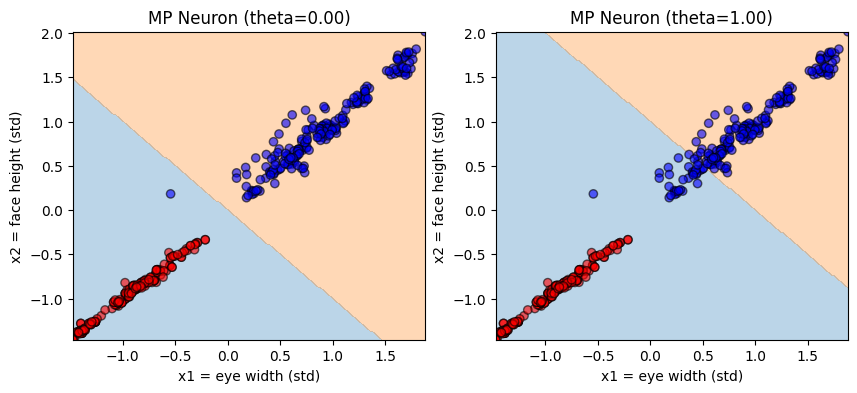


T2.3 Accuracy (MP neuron with standardized inputs):
 theta=0.00 -> accuracy = 0.0025
 theta=1.00 -> accuracy = 0.0863


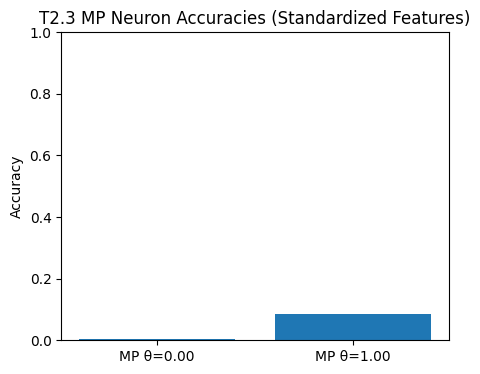

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler

# --- Standardization step ---
scaler = StandardScaler()
df[['eye_width_std','face_height_std']] = scaler.fit_transform(
    df[['eye_width','face_height']]
)

# --- Use standardized continuous features directly ---
df['x1'] = df['eye_width_std']
df['x2'] = df['face_height_std']

# T2.1: Show statistics of x1, x2 split into bins for interpretability
# Instead of discrete combos, we bucket into 0/1 by mean for reporting
eye_mean = df['x1'].mean()
face_mean = df['x2'].mean()

rows = []
print("\nT2.1 Combination frequencies (based on mean threshold bucketing):")
for a,b in [(0,0),(0,1),(1,0),(1,1)]:
    subset = df[
        ((df['x1'] >= eye_mean).astype(int) == a) &
        ((df['x2'] >= face_mean).astype(int) == b)
    ]
    n_total = len(subset)
    n_class0 = len(subset[subset.label==0])
    n_class1 = len(subset[subset.label==1])
    rows.append({'x1_bucket':a,'x2_bucket':b,'total':n_total,'class0':n_class0,'class1':n_class1})
pd_combo = pd.DataFrame(rows)
print(pd_combo)
pd_combo.to_csv(os.path.join(OUT_DIR,"T2_1_combo_frequencies.csv"), index=False)

# --- MP neuron evaluation on standardized features ---
def mp_predict_cont(x1, x2, theta):
    # weights [1,1], continuous input
    s = x1 + x2
    return (s >= theta).astype(int)

# T2.2 Decision regions: plot over standardized plane
fig, axes = plt.subplots(1,2, figsize=(10,4))
for ax, theta in zip(axes, [0.0, 1.0]):  # thresholds adjusted for standardized scale
    # create a grid in standardized space
    grid_x, grid_y = np.meshgrid(np.linspace(df['x1'].min(), df['x1'].max(), 200),
                                 np.linspace(df['x2'].min(), df['x2'].max(), 200))
    grid_preds = mp_predict_cont(grid_x.ravel(), grid_y.ravel(), theta).reshape(grid_x.shape)

    ax.contourf(grid_x, grid_y, grid_preds, levels=[-0.5,0.5,1.5], colors=['C0','C1'], alpha=0.3)
    ax.scatter(df['x1'], df['x2'], c=df['label'], cmap='bwr', edgecolors='k', alpha=0.6)
    ax.set_title(f"MP Neuron (theta={theta:.2f})")
    ax.set_xlabel("x1 = eye width (std)")
    ax.set_ylabel("x2 = face height (std)")
plt.savefig(os.path.join(OUT_DIR,"T2_binary_decision_regions_standardized.png"), dpi=150)
plt.show()

# T2.3 Accuracy table
acc_results = {}
for theta in [0.0, 1.0]:   # standardized thresholds
    preds = mp_predict_cont(df['x1'].values, df['x2'].values, theta)
    acc = (preds == df['label'].values).mean()
    acc_results[theta] = acc

print("\nT2.3 Accuracy (MP neuron with standardized inputs):")
for theta,acc in acc_results.items():
    print(f" theta={theta:.2f} -> accuracy = {acc:.4f}")

# Accuracy bar chart
plt.figure(figsize=(5,4))
plt.bar([f'MP θ={t:.2f}' for t in acc_results.keys()], acc_results.values())
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("T2.3 MP Neuron Accuracies (Standardized Features)")
plt.savefig(os.path.join(OUT_DIR,"T2_mp_accuracies_standardized.png"), dpi=150)
plt.show()


Learned weights: [-0.00578275 -0.02375163]
Learned bias: 0.0
Train Accuracy: 100.00%
Test Accuracy: 100.00%
Confusion Matrix:
 [[60  0]
 [ 0 59]]


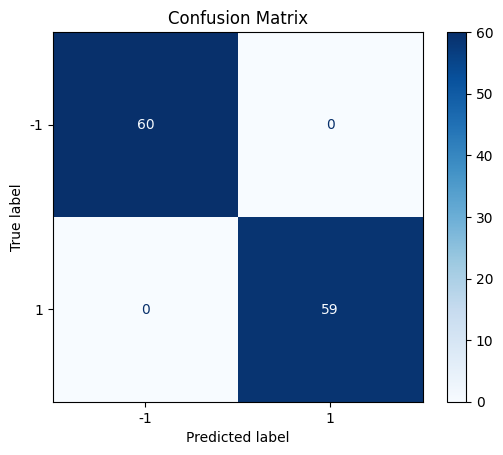

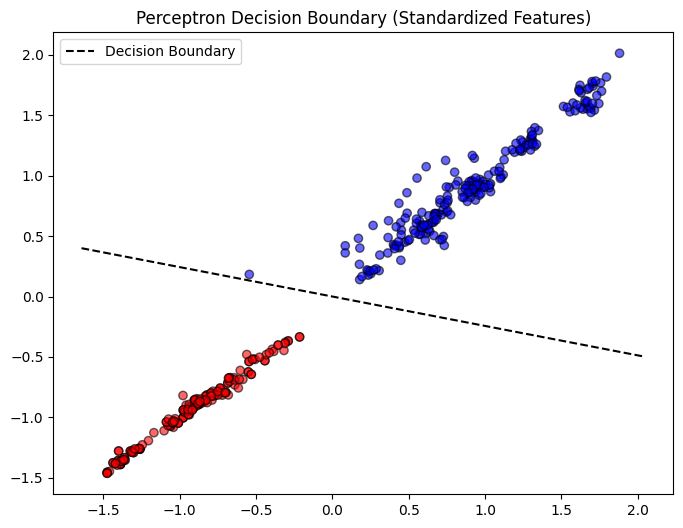

Conclusion: Data is linearly separable ✅


In [35]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------
# T3.3–T3.6 Training & Evaluation
# ------------------------------
def run_perceptron(X, y):
    # Convert targets to {-1, +1}
    classes = np.unique(y)
    y_bin = np.where(y == classes[0], -1, 1)

    # Split
    X_train, X_test, y_train, y_test = train_test_split_manual(X, y_bin)

    # Train
    clf = Perceptron(lr=0.01, epochs=1000)
    clf.fit(X_train, y_train)

    # Weights & Bias
    print("Learned weights:", clf.w)
    print("Learned bias:", clf.b)

    # Predictions
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)

    # Accuracies
    train_acc = np.mean(y_pred_train == y_train)
    test_acc = np.mean(y_pred_test == y_test)
    print(f"Train Accuracy: {train_acc*100:.2f}%")
    print(f"Test Accuracy: {test_acc*100:.2f}%")

    # Confusion Matrix (numeric + plot)
    cm = confusion_matrix(y_test, y_pred_test, labels=[-1, 1])
    print("Confusion Matrix:\n", cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 1])
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix")
    plt.show()

    # ------------------------------
    # T3.4 Decision Boundary Plot
    # ------------------------------
    plt.figure(figsize=(8,6))
    plt.scatter(X[:,0], X[:,1], c=y_bin, cmap='bwr', alpha=0.6, edgecolors='k')

    # Decision boundary line
    x_min, x_max = plt.xlim()
    x_vals = np.linspace(x_min, x_max, 100)
    y_vals = -(clf.w[0] * x_vals + clf.b) / clf.w[1]
    plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')

    # Highlight misclassified test points
    misclassified = X_test[y_test != y_pred_test]
    if len(misclassified) > 0:
        plt.scatter(misclassified[:,0], misclassified[:,1],
                    s=120, facecolors='none', edgecolors='yellow', linewidths=2, label="Misclassified")

    plt.legend()
    plt.title("Perceptron Decision Boundary (Standardized Features)")
    plt.show()

    # ------------------------------
    # T3.6 Conclusion
    # ------------------------------
    if test_acc == 1.0:
        print("Conclusion: Data is linearly separable ✅")
    else:
        print("Conclusion: Data is NOT linearly separable ❌")


# ------------------------------
# Run on standardized features
# ------------------------------
X = df[['x1', 'x2']].values.astype(float)  # standardized features
y = df['label'].values

run_perceptron(X, y)
